In [ ]:
# Import all required libraries
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

In [ ]:
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
# FIG_DIR = Path(__file__).resolve().parent / "figures"
# FIG_DIR.mkdir(exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load oil price CSV; parse dates as DD/MM/YYYY
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/oil_prices_2426.csv")
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")
df = df.set_index("date").sort_index()
price = df.squeeze()

print("Length:", len(price))
print("Date range:", price.index.min(), "to", price.index.max())
price.head(10)

Length: 500
Date range: 2024-09-21 00:00:00 to 2026-02-02 00:00:00


,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21
2024-09-26,33.38
2024-09-27,34.08
2024-09-28,34.43
2024-09-29,35.83


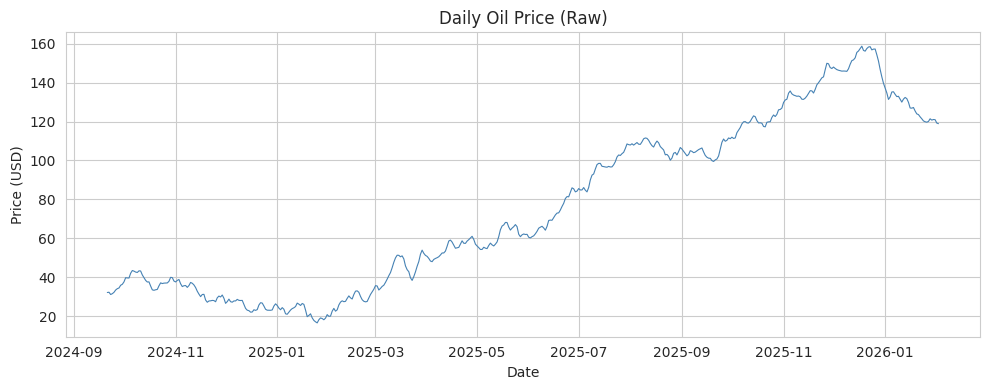

In [ ]:
# Raw series over time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price.index, price.values, color="steelblue", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.set_title("Daily Oil Price (Raw)")
plt.tight_layout()
plt.show()

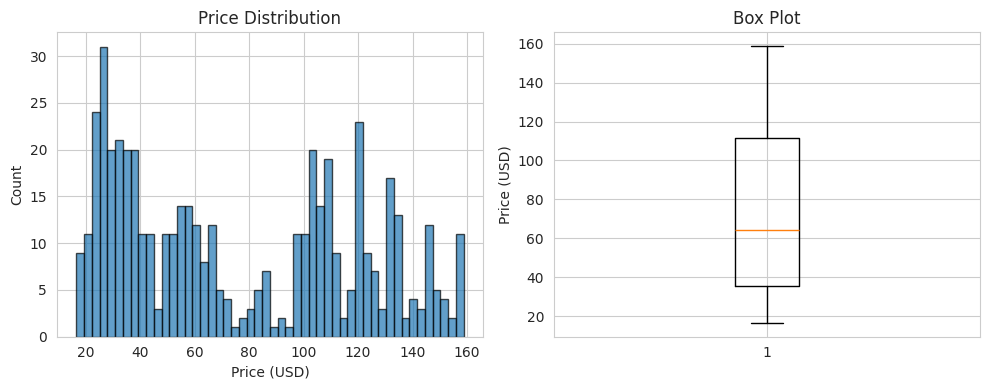

In [ ]:
# Distribution and box plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(price.dropna(), bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Count")
axes[0].set_title("Price Distribution")
axes[1].boxplot(price.dropna())
axes[1].set_ylabel("Price (USD)")
axes[1].set_title("Box Plot")
plt.tight_layout()
plt.show()

In [ ]:
# Augmented Dickey-Fuller test on level (raw series)
adf_level = adfuller(price.dropna(), autolag="AIC")
print("ADF statistic:", round(adf_level[0], 4))
print("p-value:", round(adf_level[1], 4))
print("Critical values:", adf_level[4])
if adf_level[1] > 0.05:
    print("Conclusion: series is non-stationary (fail to reject H0). Consider differencing.")
else:
    print("Conclusion: series is stationary (reject H0).")

ADF statistic: -0.5462
p-value: 0.8827
Critical values: {'1%': np.float64(-3.4439899743408136), '5%': np.float64(-2.8675550551408353), '10%': np.float64(-2.569973792117904)}
Conclusion: series is non-stationary (fail to reject H0). Consider differencing.


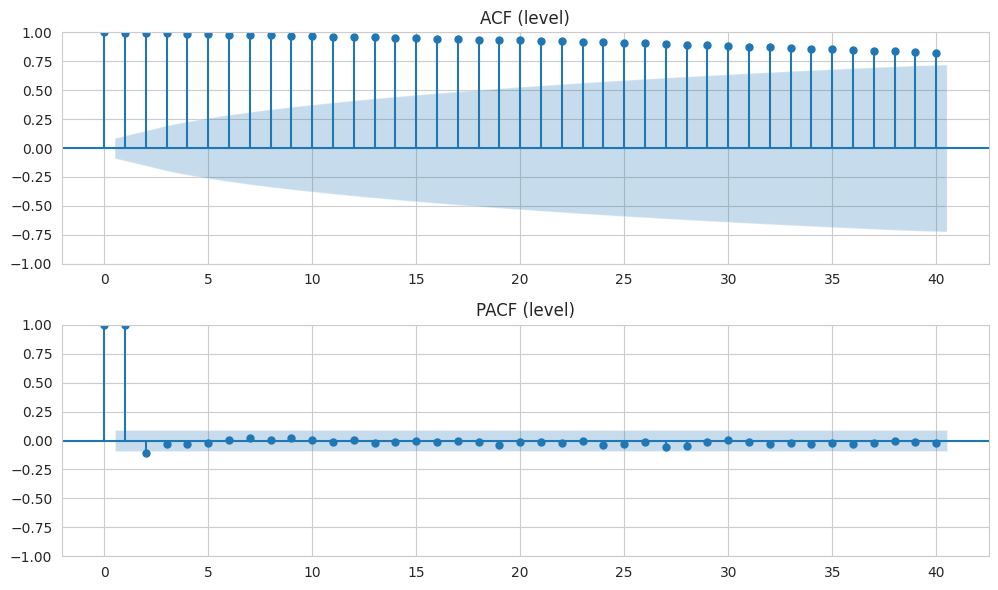

In [ ]:
# ACF and PACF on level
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(price.dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF (level)")
plot_pacf(price.dropna(), lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF (level)")
plt.tight_layout()
plt.show()

In [ ]:
# First difference
diff1 = price.diff().dropna()
adf_d1 = adfuller(diff1, autolag="AIC")
print("ADF (after 1st difference) statistic:", round(adf_d1[0], 4))
print("p-value:", round(adf_d1[1], 4))
if adf_d1[1] <= 0.05:
    print("Conclusion: differenced series is stationary.")

ADF (after 1st difference) statistic: -4.5415
p-value: 0.0002
Conclusion: differenced series is stationary.


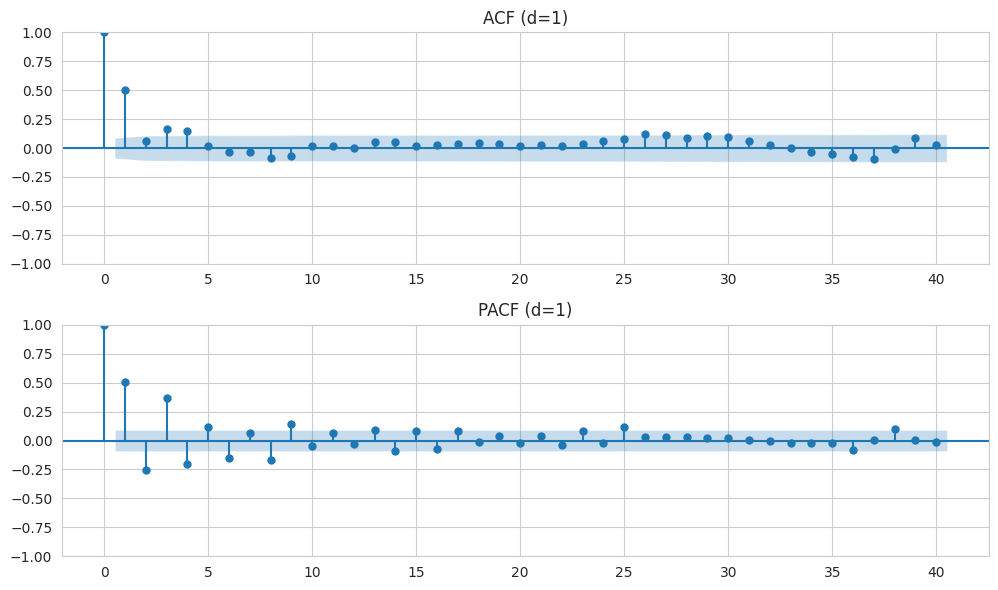

In [ ]:
# ACF and PACF on first difference
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff1, lags=40, ax=axes[0])
axes[0].set_title("ACF (d=1)")
plot_pacf(diff1, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF (d=1)")
plt.tight_layout()
plt.show()

In [ ]:
# Use last 20% as validation for RMSE/MAE
n = len(price)
train_size = int(0.8 * n)
train_ts = price.iloc[:train_size]
val_ts = price.iloc[train_size:]
print("Train length:", len(train_ts), "Validation length:", len(val_ts))

Train length: 400 Validation length: 100


In [ ]:
# Loop over p=[0,8], d=[0,2], q=[0,8]; skip (0,0,0)
results = []
for d in range(0, 3):
    for p in range(0, 9):
        for q in range(0, 9):
            if p == 0 and q == 0:
                continue
            try:
                model = ARIMA(price, order=(p, d, q))
                fit = model.fit()
                results.append(((p, d, q), fit.aic))
            except Exception:
                pass
best_pdq = min(results, key=lambda x: x[1])[0]
print("Best (p, d, q) by AIC:", best_pdq)
print("Best AIC:", min(r[1] for r in results))

In [ ]:
# Fit on training data and forecast validation period
arima_train = ARIMA(train_ts, order=best_pdq).fit()
val_pred_arima = arima_train.forecast(steps=len(val_ts))

rmse_arima_val = np.sqrt(mean_squared_error(val_ts, val_pred_arima))
mae_arima_val = mean_absolute_error(val_ts, val_pred_arima)
print("ARIMA validation RMSE:", round(rmse_arima_val, 4))
print("ARIMA validation MAE:", round(mae_arima_val, 4))

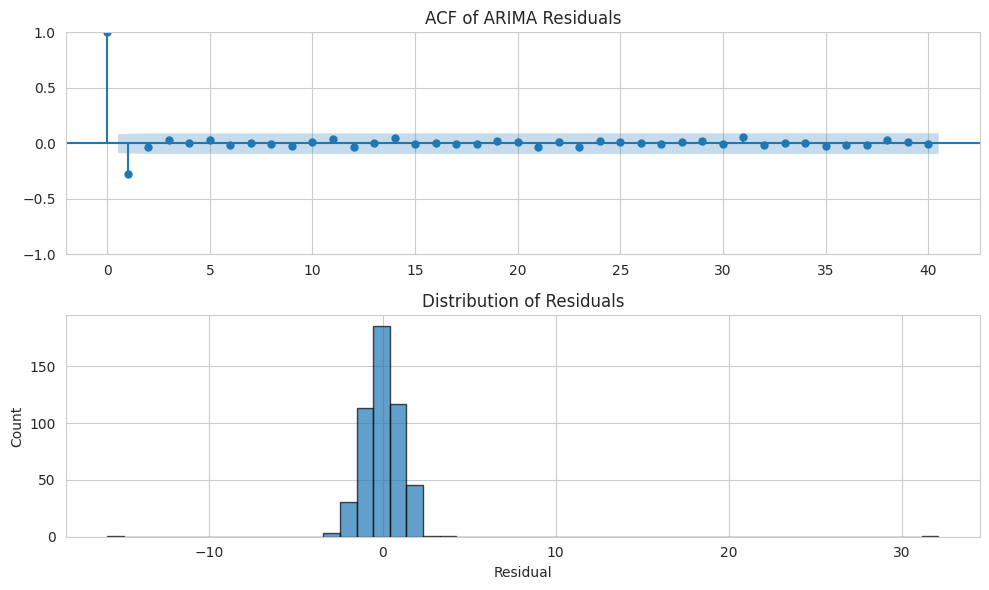

In [ ]:
# Refit on full series for final forecast
arima_full = ARIMA(price, order=best_pdq).fit()
residuals = arima_full.resid

# ACF of residuals and residual distribution
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(residuals, lags=min(40, len(residuals) // 2 - 1), ax=axes[0])
axes[0].set_title("ACF of ARIMA Residuals")
axes[1].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")
plt.tight_layout()
plt.show()

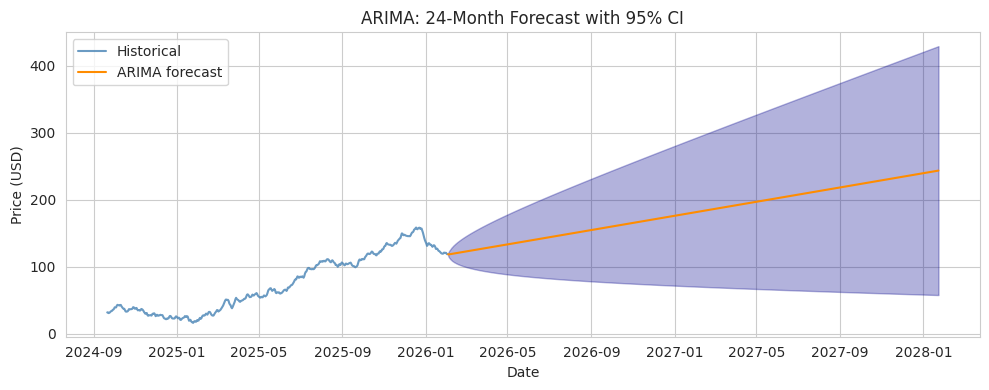

In [ ]:
# Forecast 24 months ahead (approx 720 days for daily data)
steps_24m = 24 * 30
fc_result = arima_full.get_forecast(steps=steps_24m)
arima_fc = fc_result.predicted_mean
arima_ci = fc_result.conf_int(alpha=0.05)
fc_index = pd.date_range(price.index[-1], periods=steps_24m + 1, freq="D")[1:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price.index, price.values, label="Historical", color="steelblue", alpha=0.8)
ax.plot(fc_index, arima_fc, label="ARIMA forecast", color="darkorange")
ax.fill_between(fc_index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], alpha=0.3, color="darkblue")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.set_title("ARIMA: 24-Month Forecast with 95% CI")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Scale to [0, 1] and create sequences: X[i] = last lookback values, y[i] = next value
lookback = 30
scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler.fit_transform(price.values.reshape(-1, 1)).ravel()

X_list, Y_list = [], []
for i in range(lookback, len(y_scaled)):
    X_list.append(y_scaled[i - lookback : i])
    Y_list.append(y_scaled[i])
X = np.array(X_list)
Y = np.array(Y_list)

# Train/val split (same 80/20 as before, but on sequence indices)
train_len = int(0.8 * len(X))
X_train = X[:train_len].reshape(-1, lookback, 1)
X_val = X[train_len:].reshape(-1, lookback, 1)
Y_train = Y[:train_len]
Y_val = Y[train_len:]
print("X_train shape:", X_train.shape, "Y_train shape:", Y_train.shape)

X_train shape: (376, 30, 1) Y_train shape: (376,)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.LSTM(32, input_shape=(lookback, 1), return_sequences=False),
    layers.Dense(1),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_val, Y_val), verbose=0)

In [ ]:
val_pred_lstm = model.predict(X_val, verbose=0).ravel()
val_pred_lstm_price = scaler.inverse_transform(val_pred_lstm.reshape(-1, 1)).ravel()
y_val_price = scaler.inverse_transform(Y_val.reshape(-1, 1)).ravel()

rmse_lstm_val = np.sqrt(mean_squared_error(y_val_price, val_pred_lstm_price))
mae_lstm_val = mean_absolute_error(y_val_price, val_pred_lstm_price)
print("LSTM validation RMSE:", round(rmse_lstm_val, 4))
print("LSTM validation MAE:", round(mae_lstm_val, 4))

LSTM validation RMSE: 5.8875
LSTM validation MAE: 5.0368


In [ ]:
# Point forecast: recursive
last_seq = y_scaled[-lookback:].copy()
lstm_fc = []
seq = last_seq.copy()
for _ in range(steps_24m):
    pred = model.predict(seq.reshape(1, lookback, 1), verbose=0).ravel()[0]
    lstm_fc.append(pred)
    seq = np.roll(seq, -1)
    seq[-1] = pred
lstm_fc = scaler.inverse_transform(np.array(lstm_fc).reshape(-1, 1)).ravel()

In [ ]:
# 95% CI from validation residuals
pred_val = model.predict(X_val, verbose=0).ravel()
val_pred_price = scaler.inverse_transform(pred_val.reshape(-1, 1)).ravel()
y_val_price = scaler.inverse_transform(Y_val.reshape(-1, 1)).ravel()
resid_std = np.std(y_val_price - val_pred_price)
# Constant band: point forecast ± 1.96 * residual std
lstm_lo = lstm_fc - 1.96 * resid_std
lstm_hi = lstm_fc + 1.96 * resid_std

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

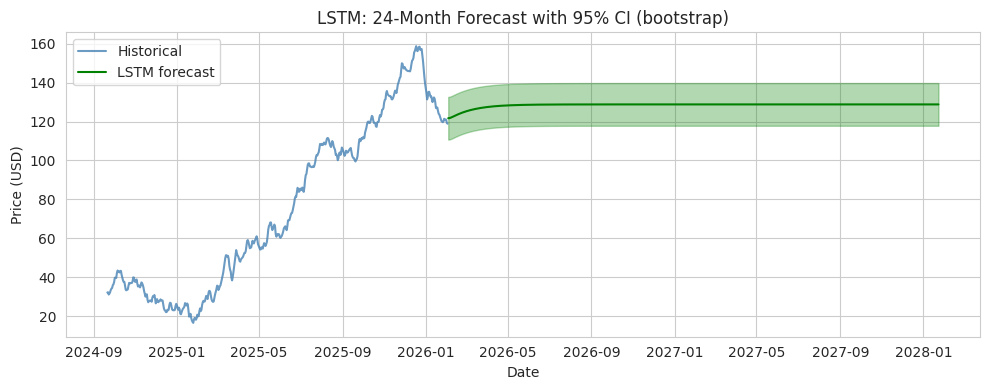

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price.index, price.values, label="Historical", color="steelblue", alpha=0.8)
ax.plot(fc_index, lstm_fc, label="LSTM forecast", color="green")
ax.fill_between(fc_index, lstm_lo, lstm_hi, alpha=0.3, color="green")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.set_title("LSTM: 24-Month Forecast with 95% CI (bootstrap)")
ax.legend()
plt.tight_layout()
plt.show()

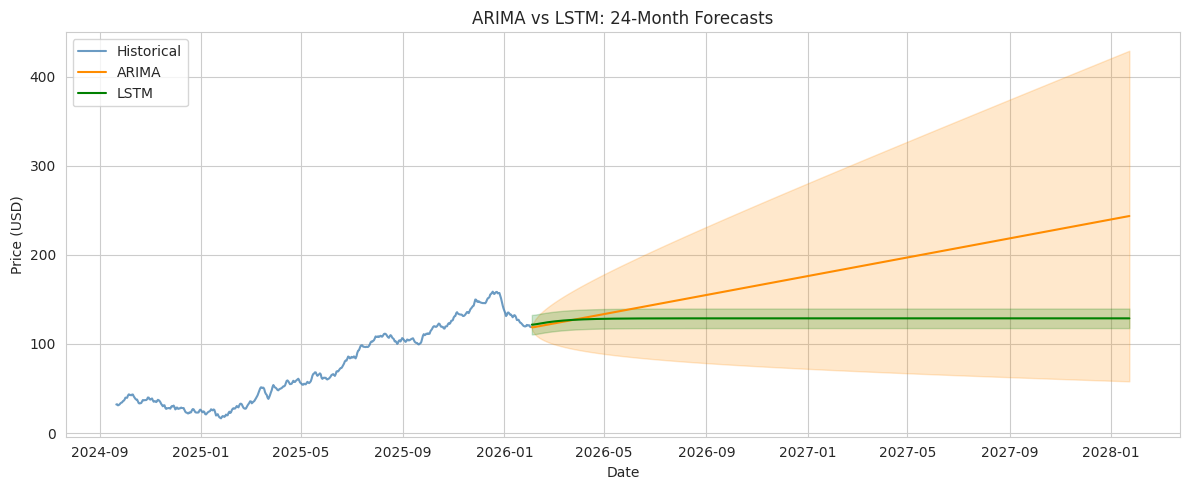

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(price.index, price.values, label="Historical", color="steelblue", alpha=0.8)
ax.plot(fc_index, arima_fc, label="ARIMA", color="darkorange")
ax.fill_between(fc_index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], alpha=0.2, color="darkorange")
ax.plot(fc_index, lstm_fc, label="LSTM", color="green")
ax.fill_between(fc_index, lstm_lo, lstm_hi, alpha=0.2, color="green")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.set_title("ARIMA vs LSTM: 24-Month Forecasts")
ax.legend()
plt.tight_layout()
plt.show()